In [1]:
import pandas as pd

# Load the SMS Spam Collection dataset
df = pd.read_csv(
    r"C:\Users\m.arasteh\data\dataset.csv",
    sep=",",
    header=None,
    names=["label", "text"]
)

# Display the first five samples
df.head()

,label,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [2]:
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first five rows after shuffling
df.head()

,label,text
0,ham,whats that coming over the hill is it a monste...
1,ham,i ve also just tried doing rpm rebuilddb no ch...
2,ham,friday brown bag on derivative pricing hello a...
3,ham,pdo index updateforwarded by mike a roberts ho...
4,spam,▫️add member dear aftab ashiq आपको अपने 5 cont...


In [3]:
# Count the number of messages in each class
class_counts = df["label"].value_counts()

# Or you can use:
class_counts = df.label.value_counts()

print(class_counts)

label
ham     14337
spam     6011
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Split the dataset into training and testing sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Reset row indices
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples : {len(test_df)}")

Training samples: 16278
Testing samples : 4070


In [6]:
# Our label column contains values: ham and spam instead of 0 and 1
# We convert the labels to 0 and 1.
train_df["label"] = train_df["label"].map({
    "ham": 0,
    "spam": 1
})

test_df["label"] = test_df["label"].map({
    "ham": 0,
    "spam": 1
})

In [7]:
# Check the labels.
print(train_df["label"].unique())

[0 1]


In [8]:
from collections import Counter
import re
import torch

# Parameters
max_tokens = 10000
sequence_length = 30

def tokenize(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

     # Split on whitespace
    return text.split()

In [9]:
counter = Counter()

for text in train_df["text"]:
    counter.update(tokenize(text))

# Reserve two special tokens
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in counter.most_common(max_tokens - 2):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 10000


In [10]:
def vectorize(text):
    tokens = tokenize(text)

    ids = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    # Truncate
    ids = ids[:sequence_length]

    # Pad
    ids += [vocab["<PAD>"]] * (sequence_length - len(ids))

    return torch.tensor(ids, dtype=torch.long)

In [11]:
sample = train_df["text"].iloc[0]

print("Original text:")
print(sample)

print("\nToken IDs:")
print(vectorize(sample))

print("\nShape:")
print(vectorize(sample).shape)

Original text:
position report for dual trigger product vince i have enclosed a summary of our proposed approach on calculation of notional and the greeks for dual trigger option portfolio please let us know your thoughts comments amitava

Token IDs:
tensor([ 487,  448,   11, 4137, 5395,  630,   24,    4,   20, 2884,    6, 1087,
           9,   46, 1881, 1393,   13, 3316,    9,    1,    5,    2,    1,   11,
        4137, 5395,  468, 1882,   42,  112])

Shape:
torch.Size([30])


In [12]:
import torch.nn as nn

vocab_size = len(vocab)
embedding_dim = 128

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=embedding_dim,
    padding_idx=0
)

In [13]:
from torch.utils.data import Dataset

class SMSDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        x = vectorize(self.texts[idx])

        y = torch.tensor(
            self.labels[idx],
            dtype=torch.float32
        )

        return x, y

In [14]:
train_dataset = SMSDataset(train_df)
test_dataset = SMSDataset(test_df)

In [15]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [16]:
import torch.nn.init as init

init.xavier_uniform_(embedding.weight)

Parameter containing:
tensor([[ 0.0153, -0.0052, -0.0105,  ..., -0.0013,  0.0067, -0.0215],
        [ 0.0155, -0.0137, -0.0035,  ..., -0.0140,  0.0231, -0.0127],
        [-0.0154,  0.0141, -0.0098,  ..., -0.0062,  0.0055,  0.0149],
        ...,
        [ 0.0190, -0.0057, -0.0241,  ...,  0.0151, -0.0164, -0.0196],
        [ 0.0063, -0.0190,  0.0206,  ...,  0.0035, -0.0012,  0.0014],
        [ 0.0082,  0.0042, -0.0234,  ..., -0.0233,  0.0194,  0.0232]],
       requires_grad=True)

In [17]:
import torch

# Two tokenized SMS messages
input_ids = torch.tensor([
    [324, 12, 48, 97, 5, 221, 0, 0],
    [42, 91, 7, 18, 5, 0, 0, 0]
])

# Convert token IDs into word embeddings
embedded = embedding(input_ids)

print("Input shape :", input_ids.shape)
print("Output shape:", embedded.shape)

Input shape : torch.Size([2, 8])
Output shape: torch.Size([2, 8, 128])


In [18]:
print(embedded[0,0])

tensor([-0.0116,  0.0066,  0.0227,  0.0106, -0.0223, -0.0113, -0.0175,  0.0095,
         0.0117, -0.0182,  0.0176,  0.0116, -0.0243, -0.0219, -0.0007,  0.0128,
        -0.0077,  0.0006,  0.0042, -0.0214,  0.0240,  0.0013, -0.0155,  0.0097,
         0.0200,  0.0022,  0.0157,  0.0220, -0.0062,  0.0042,  0.0102,  0.0207,
        -0.0136, -0.0156, -0.0001, -0.0016,  0.0021, -0.0026, -0.0125,  0.0152,
         0.0087, -0.0178,  0.0221,  0.0047,  0.0095,  0.0153, -0.0199,  0.0130,
        -0.0158, -0.0058,  0.0209, -0.0194,  0.0048, -0.0028, -0.0037, -0.0016,
        -0.0111,  0.0157,  0.0086,  0.0234,  0.0199,  0.0027, -0.0242,  0.0147,
         0.0104, -0.0064,  0.0154,  0.0203, -0.0092,  0.0187, -0.0211, -0.0147,
        -0.0020,  0.0195, -0.0161,  0.0059,  0.0173, -0.0026, -0.0175, -0.0037,
        -0.0025, -0.0149, -0.0048,  0.0112,  0.0112, -0.0045,  0.0038, -0.0125,
        -0.0027,  0.0237,  0.0136, -0.0130, -0.0020,  0.0237,  0.0107, -0.0191,
         0.0005,  0.0035, -0.0086, -0.00

In [19]:
import random
import torch

# ---------------------------------------------------------
# Select a random SMS message from the training dataset
# ---------------------------------------------------------
random_sentence = random.choice(train_df["text"])

print("Original Text:")
print(random_sentence)

# ---------------------------------------------------------
# Convert the text into token IDs
# ---------------------------------------------------------
token_ids = vectorize(random_sentence)

print("\nToken IDs:")
print(token_ids)

print("\nToken IDs Shape:")
print(token_ids.shape)

# ---------------------------------------------------------
# Add a batch dimension
# Shape: (sequence_length,) -> (1, sequence_length)
# ---------------------------------------------------------
token_ids = token_ids.unsqueeze(0)

print("\nInput to Embedding Layer:")
print(token_ids.shape)

# ---------------------------------------------------------
# Convert token IDs into embedding vectors
# ---------------------------------------------------------
embedded = embedding(token_ids)

print("\nEmbedding Tensor Shape:")
print(embedded.shape)

print("\nFirst two Word Embeddings:")
print(embedded[0, :2])

Original Text:
nokia phone is lovly

Token IDs:
tensor([2024,  172,   12,    1,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])

Token IDs Shape:
torch.Size([30])

Input to Embedding Layer:
torch.Size([1, 30])

Embedding Tensor Shape:
torch.Size([1, 30, 128])

First two Word Embeddings:
tensor([[-1.0383e-02,  8.1419e-04, -1.4335e-02, -1.7235e-02,  1.3706e-02,
          1.7701e-02,  1.1514e-02,  2.1496e-02,  1.8907e-02, -2.0697e-02,
         -3.6301e-03, -2.2216e-02, -1.6193e-02,  7.3810e-03,  6.4607e-03,
         -2.0187e-02, -2.0702e-02, -1.5501e-02,  1.5856e-02, -6.6375e-03,
         -2.4027e-02, -1.9643e-02, -2.2500e-02,  1.5217e-02, -3.4063e-03,
         -4.3736e-03,  2.2663e-04,  2.1067e-02, -2.4216e-03,  1.9490e-02,
          1.6513e-02, -1.0436e-02, -5.0644e-03, -1.2938e-02, -2.2688e-02,
          2.3538e-02, -6.0452e-04,  6.2926e-04,  1.1994e-02, -1.5965e

In [20]:
import torch
import torch.nn as nn

class FeedForwardClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Feed-forward classifier
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Convert token IDs to word embeddings
        x = self.embedding(x)

        # Average the embeddings across the sequence dimension
        x = x.mean(dim=1)

        # Classification
        x = self.classifier(x)

        return x

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64

model_FFNN = FeedForwardClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim
).to(device)

print(model_FFNN)

cpu
FeedForwardClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


In [22]:
import torch.optim as optim

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model_FFNN.parameters(),
    lr=0.0001
)

In [23]:
def accuracy_fn(y_true, y_pred):

    predictions = (y_pred >= 0.5).float()

    correct = (predictions == y_true).sum().item()

    accuracy = correct / len(y_true)

    return accuracy

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, test_loader, epochs=10):

    # Move model to device
    model = model.to(device)

    # Store the training history
    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    num_epochs = epochs

    for epoch in range(num_epochs):

        # -----------------------
        # Training phase
        # -----------------------
        model.train()

        running_loss = 0.0
        running_accuracy = 0.0

        for inputs, labels in train_loader:

            # Move data to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs).squeeze()

            # Compute loss
            loss = criterion(outputs, labels)

            # Compute accuracy
            accuracy = accuracy_fn(labels, outputs)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            running_loss += loss.item()
            running_accuracy += accuracy


        # Average training metrics
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_accuracy = running_accuracy / len(train_loader)


        # -----------------------
        # Evaluation phase
        # -----------------------
        model.eval()

        test_loss = 0.0
        test_accuracy = 0.0

        with torch.no_grad():

            for inputs, labels in test_loader:

                # Move data to device
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs).squeeze()

                loss = criterion(outputs, labels)

                accuracy = accuracy_fn(labels, outputs)

                test_loss += loss.item()
                test_accuracy += accuracy


        # Average test metrics
        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_accuracy = test_accuracy / len(test_loader)


        # Store metrics
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)

        train_accuracies.append(epoch_train_accuracy)
        test_accuracies.append(epoch_test_accuracy)


        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} "
            f"Train Accuracy: {epoch_train_accuracy:.4f} "
            f"Test Loss: {epoch_test_loss:.4f} "
            f"Test Accuracy: {epoch_test_accuracy:.4f}"
        )


    return train_losses, test_losses, train_accuracies, test_accuracies

In [25]:
train_losses_FFNN, test_losses_FFNN, train_accuracies_FFNN, test_accuracies_FFNN = train_model(
    model = model_FFNN,
    train_loader = train_loader,
    test_loader = test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 0.6168 Train Accuracy: 0.7473 Test Loss: 0.5523 Test Accuracy: 0.7738
Epoch [2/10] Train Loss: 0.5157 Train Accuracy: 0.7829 Test Loss: 0.4739 Test Accuracy: 0.8092
Epoch [3/10] Train Loss: 0.4404 Train Accuracy: 0.8283 Test Loss: 0.4017 Test Accuracy: 0.8468
Epoch [4/10] Train Loss: 0.3701 Train Accuracy: 0.8659 Test Loss: 0.3427 Test Accuracy: 0.8778
Epoch [5/10] Train Loss: 0.3149 Train Accuracy: 0.8894 Test Loss: 0.2997 Test Accuracy: 0.8868
Epoch [6/10] Train Loss: 0.2736 Train Accuracy: 0.9051 Test Loss: 0.2690 Test Accuracy: 0.8988
Epoch [7/10] Train Loss: 0.2427 Train Accuracy: 0.9153 Test Loss: 0.2463 Test Accuracy: 0.9084
Epoch [8/10] Train Loss: 0.2188 Train Accuracy: 0.9227 Test Loss: 0.2302 Test Accuracy: 0.9125
Epoch [9/10] Train Loss: 0.1999 Train Accuracy: 0.9299 Test Loss: 0.2168 Test Accuracy: 0.9181
Epoch [10/10] Train Loss: 0.1841 Train Accuracy: 0.9352 Test Loss: 0.2063 Test Accuracy: 0.9225


In [26]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    
    # Number of epochs
    epochs = range(1, len(train_losses) + 1)
    
    
    # Create subplots
    plt.figure(figsize=(12, 5))
    
    
    # -----------------------------
    # Plot Training and Test Loss
    # -----------------------------
    plt.subplot(1, 2, 1)
    
    plt.plot(
        epochs,
        train_losses,
        marker='o',
        label="Training Loss"
    )
    
    plt.plot(
        epochs,
        test_losses,
        marker='s',
        label="Test Loss"
    )
    
    plt.title("Training and Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    
    
    
    # -----------------------------
    # Plot Training and Test Accuracy
    # -----------------------------
    plt.subplot(1, 2, 2)
    
    plt.plot(
        epochs,
        train_accuracies,
        marker='o',
        label="Training Accuracy"
    )
    
    plt.plot(
        epochs,
        test_accuracies,
        marker='s',
        label="Test Accuracy"
    )
    
    plt.title("Training and Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    
    
    # Adjust spacing between plots
    plt.tight_layout()
    
    plt.show()


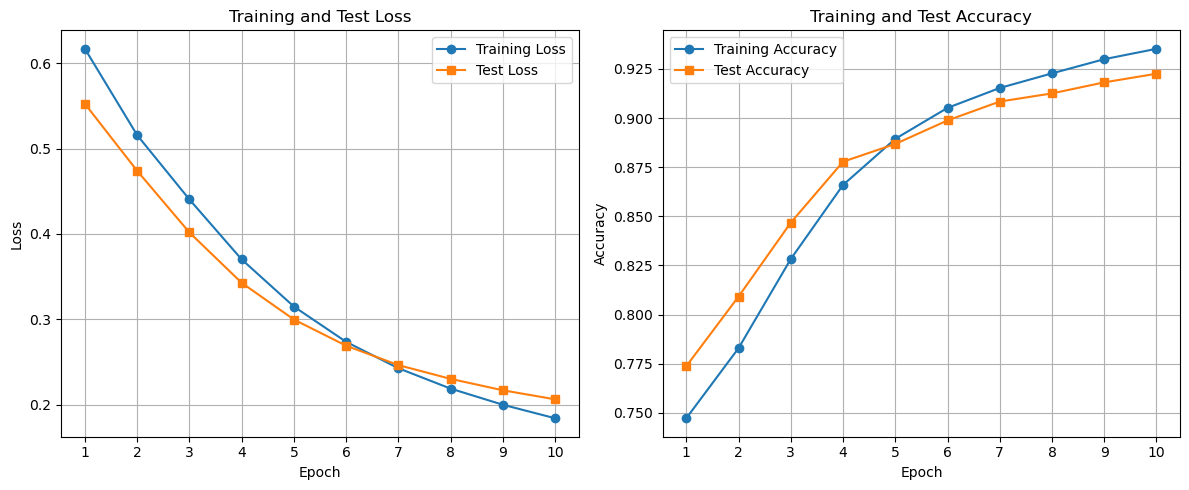

In [27]:
plot_loss_accuracy(epochs = 10, 
                   train_losses = train_losses_FFNN, 
                   test_losses = test_losses_FFNN, 
                   train_accuracies = train_accuracies_FFNN,
                  test_accuracies = test_accuracies_FFNN)

In [28]:

def evaluate(model):
    
    model.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in test_loader:
    
            outputs = model(inputs).squeeze()
    
            predictions = (outputs >= 0.5).float()
    
            total += labels.size(0)
    
            correct += (predictions == labels).sum().item()
    
    accuracy = correct / total

    print(f"Test Accuracy: {accuracy:.4f}")

evaluate(model_FFNN)

Test Accuracy: 0.9231


In [29]:
import torch

# A new SMS message
text = "URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010"

def predict(text, model):
    # Set the model to evaluation mode
    model.eval()

    with torch.no_grad():

        # Convert the text into token IDs
        x = vectorize(text)

        # Add a batch dimension
        x = x.unsqueeze(0)

        # Predict the probability of spam
        probability = model(x).item()
    
        # Convert the probability into a class label
        prediction = "spam" if probability >= 0.5 else "ham"

    print(f"Message     : {text}")
    print(f"Probability : {probability:.4f}")
    print(f"Prediction  : {prediction}")

predict(text, model_FFNN)

Message     : URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010
Probability : 0.9612
Prediction  : spam


In [30]:
# Implement an RNN with one layer of RNN

import torch
import torch.nn as nn


class RNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim
    ):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )


        # Recurrent Neural Network layer
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,         # Number of RNN layer
            batch_first=True
        )


        # Fully connected classification layer
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=1
        )

        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)


        # Process the sequence using RNN
        output, hidden = self.rnn(x)


        # Remove the first dimension
        hidden = hidden[-1]


        # Convert hidden representation into prediction
        output = self.fc(hidden)

        # Convert logits to probability
        output = self.sigmoid(output)


        return output

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64

model_RNN = RNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim
).to(device)

print(model_RNN)

cpu
RNNClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (rnn): RNN(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [32]:
import torch.optim as optim

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model_RNN.parameters(),
    lr=0.0001
)

In [33]:
train_losses_RNN, test_losses_RNN, train_accuracies_RNN, test_accuracies_RNN = train_model(
    model = model_RNN,
    train_loader = train_loader,
    test_loader = test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 0.5981 Train Accuracy: 0.6776 Test Loss: 0.5316 Test Accuracy: 0.7471
Epoch [2/10] Train Loss: 0.5000 Train Accuracy: 0.7689 Test Loss: 0.4882 Test Accuracy: 0.7840
Epoch [3/10] Train Loss: 0.4504 Train Accuracy: 0.8035 Test Loss: 0.4506 Test Accuracy: 0.8075
Epoch [4/10] Train Loss: 0.4115 Train Accuracy: 0.8269 Test Loss: 0.4208 Test Accuracy: 0.8324
Epoch [5/10] Train Loss: 0.3786 Train Accuracy: 0.8489 Test Loss: 0.3859 Test Accuracy: 0.8475
Epoch [6/10] Train Loss: 0.3484 Train Accuracy: 0.8666 Test Loss: 0.3719 Test Accuracy: 0.8520
Epoch [7/10] Train Loss: 0.3239 Train Accuracy: 0.8782 Test Loss: 0.3449 Test Accuracy: 0.8691
Epoch [8/10] Train Loss: 0.2989 Train Accuracy: 0.8891 Test Loss: 0.3246 Test Accuracy: 0.8761
Epoch [9/10] Train Loss: 0.2749 Train Accuracy: 0.9001 Test Loss: 0.3110 Test Accuracy: 0.8791
Epoch [10/10] Train Loss: 0.2576 Train Accuracy: 0.9069 Test Loss: 0.2928 Test Accuracy: 0.8898


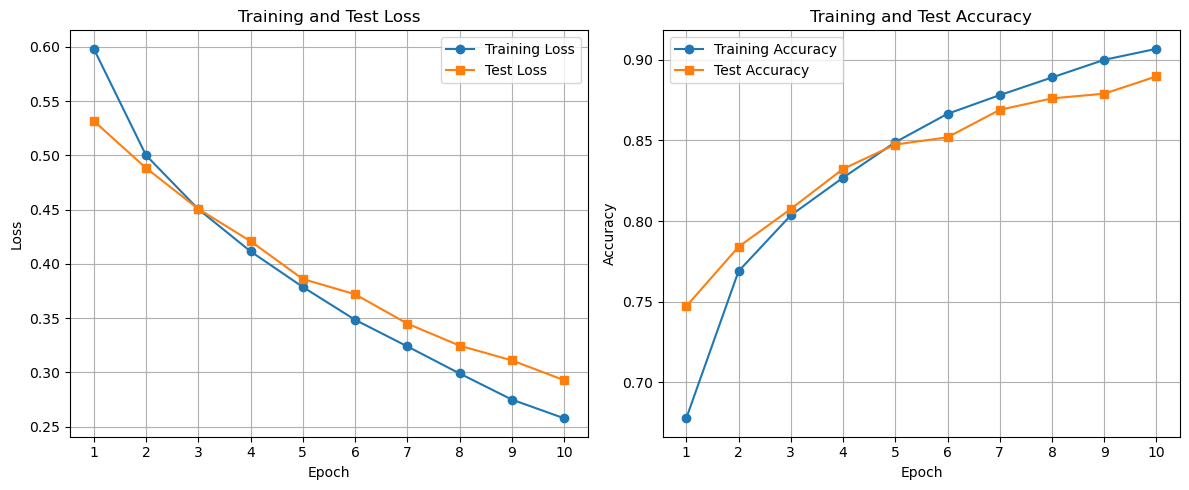

In [34]:
plot_loss_accuracy(epochs = 10, 
                   train_losses = train_losses_RNN, 
                   test_losses = test_losses_RNN, 
                   train_accuracies = train_accuracies_RNN,
                   test_accuracies = test_accuracies_RNN)

In [35]:
evaluate(model_RNN)

Test Accuracy: 0.8902


In [36]:
# A new SMS message
text = "URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010"
predict(text, model_RNN)

Message     : URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010
Probability : 0.9387
Prediction  : spam


In [37]:
import torch
import torch.nn as nn


class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim
    ):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,           # Number io LSTM Layer
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=1
        )

        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Process the sequence using LSTM
        output, (hidden, cell) = self.lstm(x)

        # Use the final hidden state
        hidden = hidden[-1]

        # Fully connected layer
        output = self.fc(hidden)

        # Convert output to probability
        output = self.sigmoid(output)

        return output

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64

model_LSTM = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim
).to(device)

print(model_LSTM)

cpu
LSTMClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [39]:
import torch.optim as optim 

criterion = nn.BCELoss() 
optimizer = optim.Adam(model_LSTM.parameters(), lr=0.0001)

In [40]:
train_losses_LSTM, test_losses_LSTM, train_accuracies_LSTM, test_accuracies_LSTM = train_model(
    model = model_LSTM,
    train_loader = train_loader,
    test_loader = test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 0.5808 Train Accuracy: 0.6808 Test Loss: 0.4376 Test Accuracy: 0.7913
Epoch [2/10] Train Loss: 0.3942 Train Accuracy: 0.8336 Test Loss: 0.3666 Test Accuracy: 0.8608
Epoch [3/10] Train Loss: 0.3327 Train Accuracy: 0.8759 Test Loss: 0.3243 Test Accuracy: 0.8767
Epoch [4/10] Train Loss: 0.2844 Train Accuracy: 0.8977 Test Loss: 0.2943 Test Accuracy: 0.8870
Epoch [5/10] Train Loss: 0.2445 Train Accuracy: 0.9140 Test Loss: 0.2659 Test Accuracy: 0.9048
Epoch [6/10] Train Loss: 0.2124 Train Accuracy: 0.9268 Test Loss: 0.2467 Test Accuracy: 0.9124
Epoch [7/10] Train Loss: 0.1838 Train Accuracy: 0.9408 Test Loss: 0.2373 Test Accuracy: 0.9172
Epoch [8/10] Train Loss: 0.1603 Train Accuracy: 0.9493 Test Loss: 0.2314 Test Accuracy: 0.9204
Epoch [9/10] Train Loss: 0.1400 Train Accuracy: 0.9569 Test Loss: 0.2250 Test Accuracy: 0.9209
Epoch [10/10] Train Loss: 0.1262 Train Accuracy: 0.9609 Test Loss: 0.2126 Test Accuracy: 0.9307


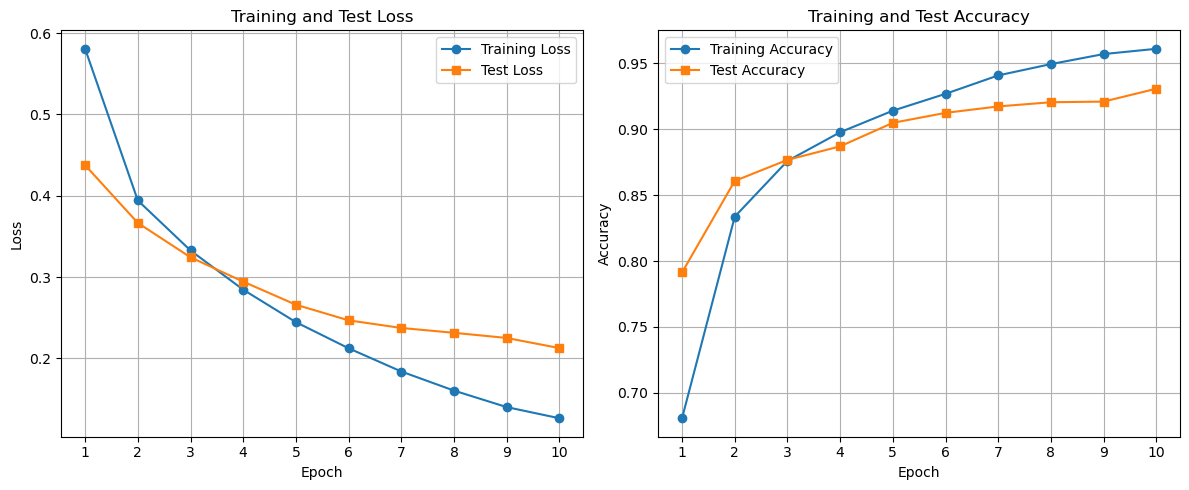

In [41]:
plot_loss_accuracy(epochs = 10, 
                   train_losses = train_losses_LSTM, 
                   test_losses = test_losses_LSTM, 
                   train_accuracies = train_accuracies_LSTM,
                   test_accuracies = test_accuracies_LSTM)

In [42]:
evaluate(model_LSTM)

Test Accuracy: 0.9302


In [43]:
# A new SMS message
text = "URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010"
predict(text, model_LSTM)

Message     : URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010
Probability : 0.9734
Prediction  : spam


In [44]:
# Implement a GRU Model

import torch
import torch.nn as nn


class GRUClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim
    ):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # GRU layer
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,       # Number of GRU layers
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=1
        )

        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Process the sequence using GRU
        output, hidden = self.gru(x)

        # Use the final hidden state
        hidden = hidden[-1]

        # Fully connected layer
        output = self.fc(hidden)

        # Convert output to probability
        output = self.sigmoid(output)

        return output

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64

model_GRU = GRUClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim
).to(device)

print(model_GRU)

cpu
GRUClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (gru): GRU(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [46]:
import torch.optim as optim

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model_GRU.parameters(),
    lr=0.0001
)

In [47]:
train_losses_GRU, test_losses_GRU, \
train_accuracies_GRU, test_accuracies_GRU = train_model(
    model=model_GRU,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 0.6061 Train Accuracy: 0.6649 Test Loss: 0.4944 Test Accuracy: 0.7669
Epoch [2/10] Train Loss: 0.4097 Train Accuracy: 0.8229 Test Loss: 0.3511 Test Accuracy: 0.8596
Epoch [3/10] Train Loss: 0.3108 Train Accuracy: 0.8783 Test Loss: 0.2930 Test Accuracy: 0.8835
Epoch [4/10] Train Loss: 0.2511 Train Accuracy: 0.9080 Test Loss: 0.2535 Test Accuracy: 0.9072
Epoch [5/10] Train Loss: 0.2135 Train Accuracy: 0.9241 Test Loss: 0.2375 Test Accuracy: 0.9104
Epoch [6/10] Train Loss: 0.1835 Train Accuracy: 0.9384 Test Loss: 0.2213 Test Accuracy: 0.9229
Epoch [7/10] Train Loss: 0.1613 Train Accuracy: 0.9469 Test Loss: 0.2163 Test Accuracy: 0.9189
Epoch [8/10] Train Loss: 0.1415 Train Accuracy: 0.9558 Test Loss: 0.2117 Test Accuracy: 0.9253
Epoch [9/10] Train Loss: 0.1256 Train Accuracy: 0.9620 Test Loss: 0.2128 Test Accuracy: 0.9307
Epoch [10/10] Train Loss: 0.1118 Train Accuracy: 0.9675 Test Loss: 0.2068 Test Accuracy: 0.9316


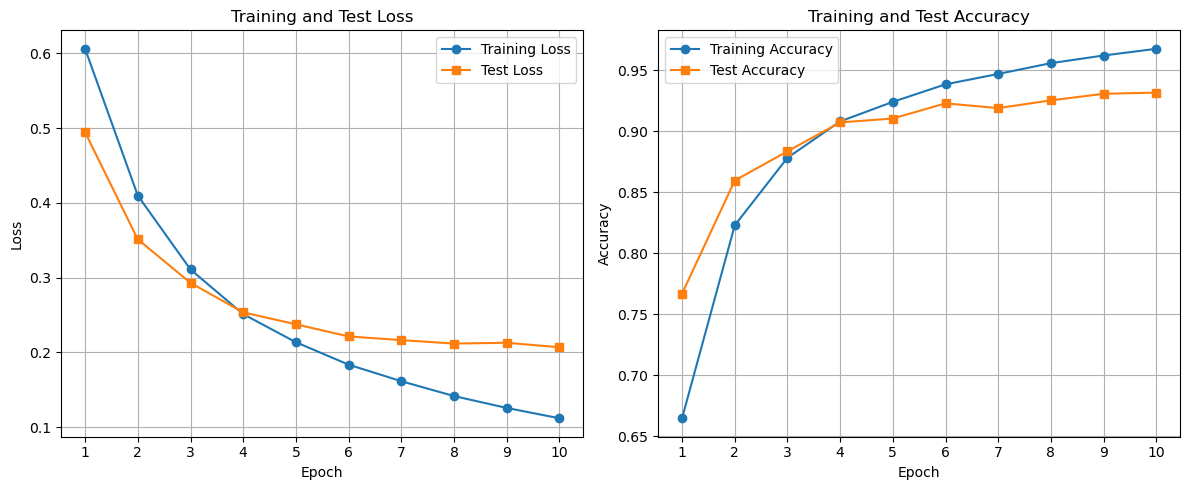

In [48]:
plot_loss_accuracy(
    epochs=10,
    train_losses=train_losses_GRU,
    test_losses=test_losses_GRU,
    train_accuracies=train_accuracies_GRU,
    test_accuracies=test_accuracies_GRU
)

In [49]:
evaluate(model_GRU)

Test Accuracy: 0.9312


In [50]:
text = "URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010"

predict(text, model_GRU)

Message     : URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010
Probability : 0.9830
Prediction  : spam


In [51]:
import torch
import torch.nn as nn


class TextCNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_filters,
        filter_sizes
    ):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Convolutional layers
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=filter_size
            )
            for filter_size in filter_sizes
        ])

        # Fully connected classification layer
        self.fc = nn.Linear(
            in_features=num_filters * len(filter_sizes),
            out_features=1
        )

        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Rearrange dimensions for Conv1d
        x = x.permute(0, 2, 1)

        # Apply convolution + ReLU + max pooling
        pooled_outputs = []

        for conv in self.convs:

            feature_map = torch.relu(conv(x))

            pooled = torch.max(
                feature_map,
                dim=2
            ).values

            pooled_outputs.append(pooled)

        # Concatenate pooled features
        x = torch.cat(
            pooled_outputs,
            dim=1
        )

        # Classification
        x = self.fc(x)

        # Convert logits to probability
        x = self.sigmoid(x)

        return x

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
num_filters = 64
filter_sizes = [2, 3, 4]


model_CNN = TextCNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_filters=num_filters,
    filter_sizes=filter_sizes
).to(device)


print(model_CNN)

cpu
TextCNNClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 64, kernel_size=(2,), stride=(1,))
    (1): Conv1d(128, 64, kernel_size=(3,), stride=(1,))
    (2): Conv1d(128, 64, kernel_size=(4,), stride=(1,))
  )
  (fc): Linear(in_features=192, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [53]:
import torch.optim as optim
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model_CNN.parameters(),
    lr=0.0001
)

In [54]:
train_losses_CNN, test_losses_CNN, \
train_accuracies_CNN, test_accuracies_CNN = train_model(
    model=model_CNN,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 0.5459 Train Accuracy: 0.7369 Test Loss: 0.4642 Test Accuracy: 0.8200
Epoch [2/10] Train Loss: 0.4120 Train Accuracy: 0.8415 Test Loss: 0.3725 Test Accuracy: 0.8534
Epoch [3/10] Train Loss: 0.3244 Train Accuracy: 0.8870 Test Loss: 0.3135 Test Accuracy: 0.8796
Epoch [4/10] Train Loss: 0.2587 Train Accuracy: 0.9170 Test Loss: 0.2655 Test Accuracy: 0.9041
Epoch [5/10] Train Loss: 0.2093 Train Accuracy: 0.9384 Test Loss: 0.2371 Test Accuracy: 0.9148
Epoch [6/10] Train Loss: 0.1714 Train Accuracy: 0.9513 Test Loss: 0.2122 Test Accuracy: 0.9209
Epoch [7/10] Train Loss: 0.1415 Train Accuracy: 0.9643 Test Loss: 0.1958 Test Accuracy: 0.9260
Epoch [8/10] Train Loss: 0.1176 Train Accuracy: 0.9733 Test Loss: 0.1835 Test Accuracy: 0.9304
Epoch [9/10] Train Loss: 0.0978 Train Accuracy: 0.9799 Test Loss: 0.1742 Test Accuracy: 0.9326
Epoch [10/10] Train Loss: 0.0816 Train Accuracy: 0.9847 Test Loss: 0.1667 Test Accuracy: 0.9355


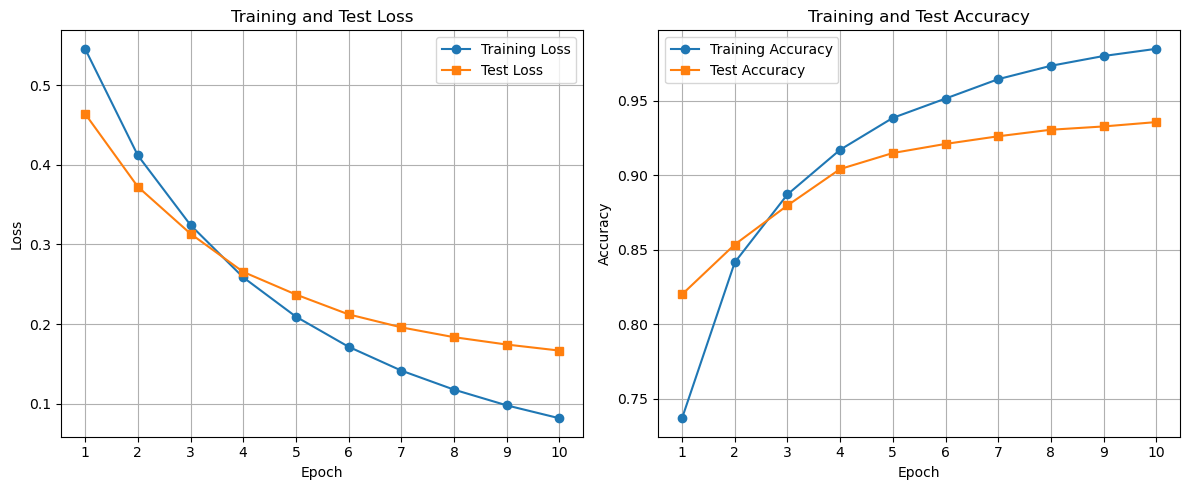

In [55]:
plot_loss_accuracy(
    epochs=10,
    train_losses=train_losses_CNN,
    test_losses=test_losses_CNN,
    train_accuracies=train_accuracies_CNN,
    test_accuracies=test_accuracies_CNN
)

In [56]:
evaluate(model_CNN)

Test Accuracy: 0.9351


In [57]:
text = "URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010"

predict(text, model_CNN)

Message     : URGENT! You have won a 1 week FREE membership in our آ£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010
Probability : 0.9945
Prediction  : spam
